# Twitter Hate Speech Classification
Davidson et al. (2017) – labeled_data.csv

Goal: Illustrate the difficulty of distinguishing hate speech (class 0) from offensive language (class 1), relevant to Meta's content moderation policy changes in 2025.

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import re
import string

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from nltk.corpus import stopwords
import nltk
nltk.download('stopwords', quiet=True)

True

## 1. Load and explore

In [63]:
df = pd.read_csv("../data/labeled_data.csv", index_col=0)

print(df.shape)
print(df.dtypes)
print("\nMissing values:")
print(df[["tweet", "class"]].isnull().sum())
df.head()

(24783, 6)
count                  int64
hate_speech            int64
offensive_language     int64
neither                int64
class                  int64
tweet                 object
dtype: object

Missing values:
tweet    0
class    0
dtype: int64


,count,hate_speech,offensive_language,neither,class,tweet
0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


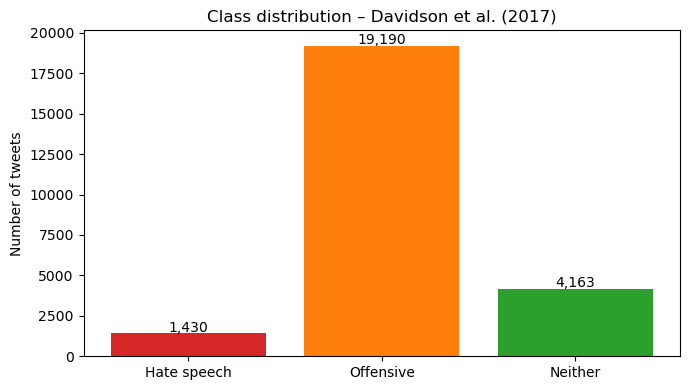

Hate speech     1430
Offensive      19190
Neither         4163


In [64]:
# Class distribution
label_names = {0: "Hate speech", 1: "Offensive", 2: "Neither"}
counts = df["class"].value_counts().sort_index()
counts.index = [label_names[i] for i in counts.index]

plt.figure(figsize=(7, 4))
bars = plt.bar(counts.index, counts.values, color=["#d62728", "#ff7f0e", "#2ca02c"])
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
             f"{val:,}", ha="center", fontsize=10)
plt.title("Class distribution – Davidson et al. (2017)")
plt.ylabel("Number of tweets")
plt.tight_layout()
plt.show()

print(counts.to_string())

## 2. Preprocess tweets

In [65]:
stop_words = set(stopwords.words("english"))

def preprocess(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)       # remove URLs
    text = re.sub(r"@\w+", "", text)                  # remove mentions
    text = re.sub(r"#\w+", "", text)                  # remove hashtags
    text = re.sub(r"rt\s", "", text)                  # remove retweet marker
    text = text.translate(str.maketrans("", "", string.punctuation))  # remove punctuation
    text = re.sub(r"\d+", "", text)                   # remove digits
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    return " ".join(tokens)

df["clean"] = df["tweet"].apply(preprocess)

# Sanity check
print("Original: ", df["tweet"].iloc[0])
print("Cleaned:  ", df["clean"].iloc[0])

Original:  !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...
Cleaned:   woman shouldnt complain cleaning house amp man always take trash


## 3. TF-IDF features (unigrams + bigrams)

In [66]:
# Use unigrams and bigrams, limit vocabulary to top 20 000 terms
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=20000, min_df=3)

X = tfidf.fit_transform(df["clean"])
y = df["class"]

print(f"Feature matrix: {X.shape}")

Feature matrix: (24783, 12887)


## 4. Train logistic regression

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# class_weight='balanced' compensates for the skewed class distribution
clf = LogisticRegression(max_iter=1000, class_weight="balanced", C=1.0, solver="lbfgs", multi_class="multinomial")
clf.fit(X_train, y_train)

print("Training done.")

/Users/adnerolstad/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training done.


## 5. Evaluate – confusion matrix and classification report

In [68]:
y_pred = clf.predict(X_test)

print(classification_report(
    y_test, y_pred,
    target_names=["Hate speech (0)", "Offensive (1)", "Neither (2)"]
))

                 precision    recall  f1-score   support

Hate speech (0)       0.35      0.60      0.44       286
  Offensive (1)       0.97      0.86      0.91      3838
    Neither (2)       0.75      0.95      0.84       833

       accuracy                           0.86      4957
      macro avg       0.69      0.81      0.73      4957
   weighted avg       0.90      0.86      0.87      4957



In [69]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy (logistic regression): {accuracy:.1%}")

Accuracy (logistic regression): 86.1%


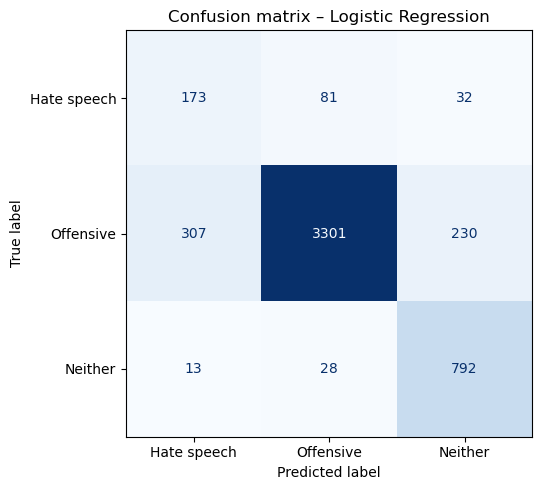

In [70]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Hate speech", "Offensive", "Neither"]
)

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion matrix – Logistic Regression")
plt.tight_layout()
plt.show()

## 6. Top 15 most important features per class

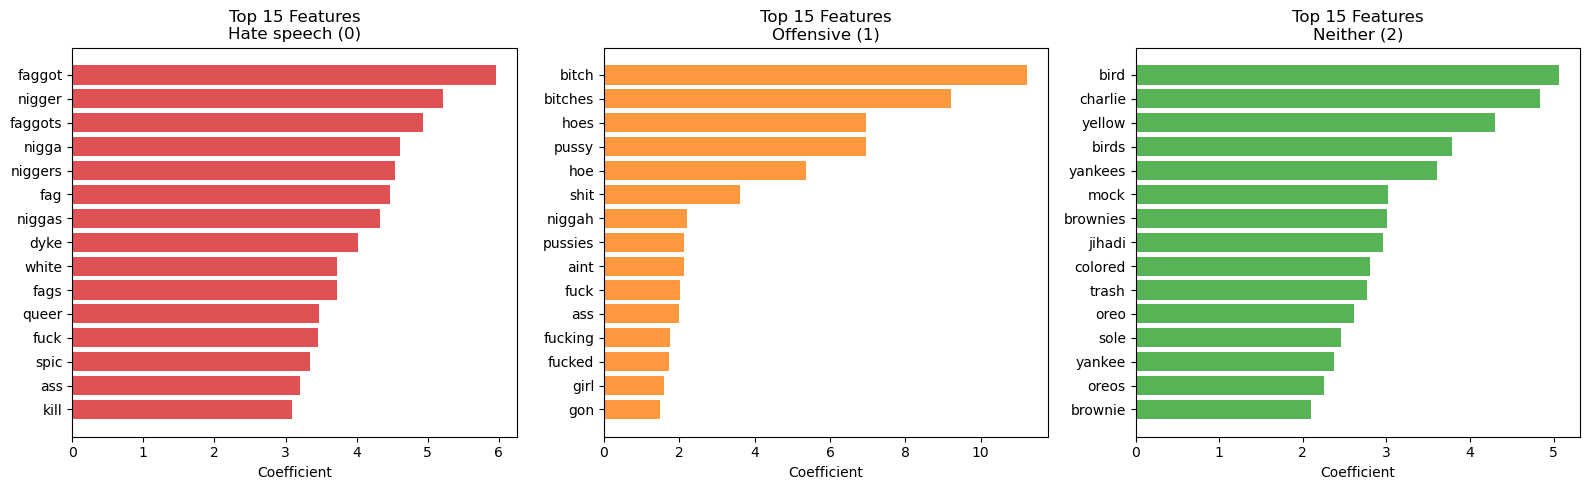

In [71]:
feature_names = np.array(tfidf.get_feature_names_out())
class_labels = ["Hate speech (0)", "Offensive (1)", "Neither (2)"]
colors = ["#d62728", "#ff7f0e", "#2ca02c"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (ax, label, color) in enumerate(zip(axes, class_labels, colors)):
    coef = clf.coef_[i]
    top_idx = np.argsort(coef)[-15:][::-1]
    ax.barh(range(15), coef[top_idx][::-1], color=color, alpha=0.8)
    ax.set_yticks(range(15))
    ax.set_yticklabels(feature_names[top_idx][::-1])
    ax.set_title(f"Top 15 Features\n{label}")
    ax.set_xlabel("Coefficient")

plt.tight_layout()
plt.savefig("../figurer/top_features_davidson_logreg.pdf.pdf", bbox_inches="tight")

plt.show()

## 7. Where the model struggles most

The confusion matrix reveals that the most common error is **misclassifying hate speech (class 0) as offensive language (class 1)**. This is not a modelling failure — it reflects genuine ambiguity in the data itself.

**Why class 0 and 1 are hard to separate:**
- Both classes share slurs and profanity. The difference is *intent and target*: hate speech dehumanises a group, while offensive language may just be crude or aggressive without targeting identity.
- Davidson et al. (2017) show that the dataset is annotator-dependent — annotators disagreed most on the 0/1 boundary.
- The model sees surface tokens, not context, speaker identity, or irony.

**Relevance to Meta's 2025 policy changes:**
The same ambiguity that challenges this classifier challenges Meta's automated systems. When Meta relaxed its hate speech rules in January 2025, it effectively redrew the line between class 0 and class 1 — moving some content that was previously actioned (class 0) into a tolerated zone (class 1). The high confusion between these classes in a supervised model suggests that even with labeled training data, this boundary is unstable, and small policy shifts can have large downstream effects on what gets removed.

## 8. Random Forest – trening og sammenligning med logistisk regresjon

In [72]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Random Forest på samme X_train/X_test som logistisk regresjon
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(
    y_test, y_pred_rf,
    target_names=["Hate speech (0)", "Offensive (1)", "Neither (2)"]
))

# Sammenlign macro F1 mellom de to modellene
f1_lr = f1_score(y_test, y_pred, average="macro")
f1_rf = f1_score(y_test, y_pred_rf, average="macro")
print(f"Macro F1 – Logistisk regresjon : {f1_lr:.3f}")
print(f"Macro F1 – Random Forest       : {f1_rf:.3f}")

=== Random Forest ===
                 precision    recall  f1-score   support

Hate speech (0)       0.54      0.18      0.27       286
  Offensive (1)       0.92      0.95      0.94      3838
    Neither (2)       0.81      0.88      0.84       833

       accuracy                           0.90      4957
      macro avg       0.76      0.67      0.68      4957
   weighted avg       0.88      0.90      0.88      4957

Macro F1 – Logistisk regresjon : 0.731
Macro F1 – Random Forest       : 0.684


## 9. Feature importance – topp 15 ord per klasse (Random Forest)

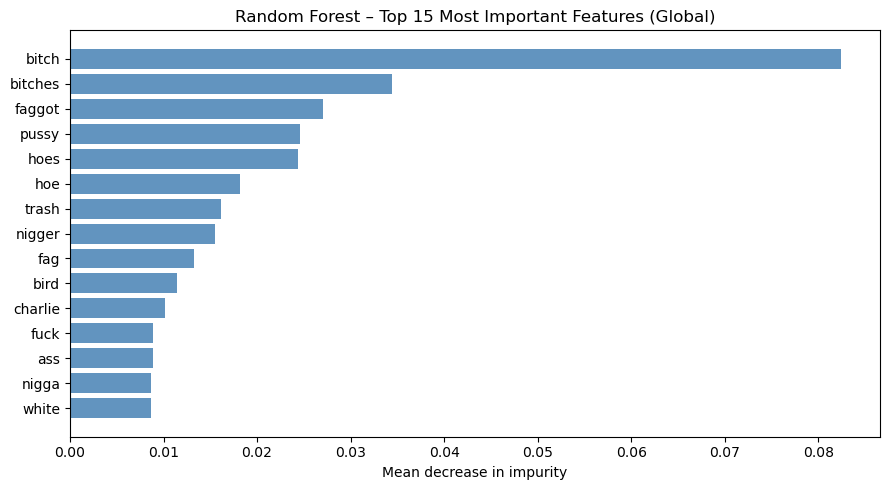

In [73]:
importances = rf.feature_importances_
feature_names = np.array(tfidf.get_feature_names_out())

top_global_idx = np.argsort(importances)[-15:][::-1]

plt.figure(figsize=(9, 5))
plt.barh(range(15), importances[top_global_idx][::-1], color="steelblue", alpha=0.85)
plt.yticks(range(15), feature_names[top_global_idx][::-1])
plt.xlabel("Mean decrease in impurity")
plt.title("Random Forest – Top 15 Most Important Features (Global)")
plt.tight_layout()
plt.show()

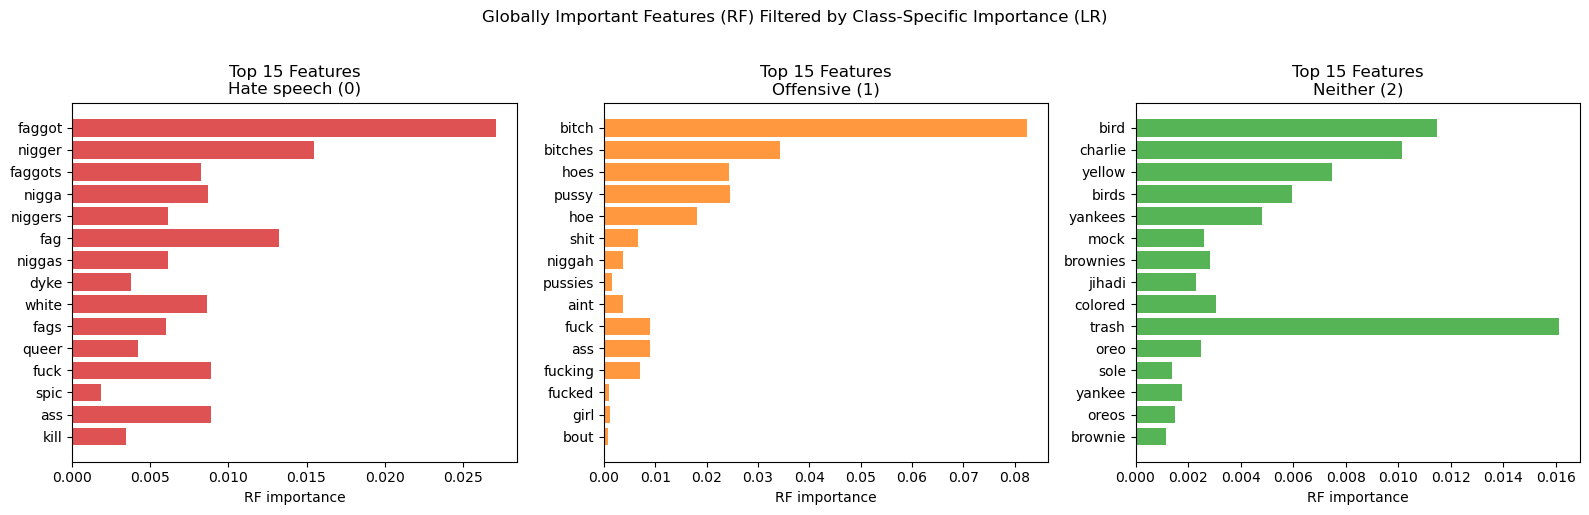

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (ax, label, color) in enumerate(zip(axes, class_labels, colors)):
    lr_coef = clf.coef_[i]
    top200_rf = np.argsort(importances)[-200:]
    top200_lr = top200_rf[np.argsort(lr_coef[top200_rf])[-15:][::-1]]

    words = feature_names[top200_lr]
    scores = importances[top200_lr]

    ax.barh(range(15), scores[::-1], color=color, alpha=0.8)
    ax.set_yticks(range(15))
    ax.set_yticklabels(words[::-1])
    ax.set_title(f"Top 15 Features\n{label}")
    ax.set_xlabel("RF importance")

plt.suptitle("Globally Important Features (RF) Filtered by Class-Specific Importance (LR)", y=1.02)
plt.tight_layout()
plt.savefig("../figurer/top_features_davidson_rf.pdf", bbox_inches="tight")

plt.show()